# Flood Risk Preprocessing Pipeline
**IDS 705 Final Project - Group 7: The Floodgates**

This notebook covers all preprocessing steps for the Flood Prediction Dataset:
1. Load & initial inspection
2. Data quality checks (missing values, duplicates, outliers)
3. Summary statistics & distribution analysis
4. Correlation matrix
5. VIF (Variance Inflation Factor) analysis
6. Feature scaling (StandardScaler)
7. Train/test split + 5-fold cross-validation setup
8. Save model-ready datasets

## 0. Imports

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings

warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Data & Initial Inspection

In [102]:
df = pd.read_csv("data/flood.csv")  # update path if needed

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Shape: (50000, 21)
Rows: 50,000 | Columns: 21


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [103]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

# 2. Injecting Real-World Simulation (Noise)
Our function improves the realism of the synthetic flood prediction dataset by introducing both structured complexity and controlled uncertainty. First, it adds smooth non-linear interaction effects between key variables, such as high monsoon intensity combined with severe deforestation, or poor infrastructure combined with high population density, reflecting how flood risk increases more sharply when multiple adverse conditions occur together rather than independently. These effects are implemented using gradual activation, instead of hard thresholds, making the relationships more natural and learnable. Next, the function injects heteroskedastic noise, meaning the amount of randomness scales with the predicted flood probability, which mimics real-world conditions where extreme events are inherently more uncertain than mild ones. Finally, the results are clipped to ensure all values remain valid probabilities between 0 and 1. Importantly, this transformation preserves the overall distribution of the dataset (with only a minimal change in mean) while increasing variability and reducing artificial linearity, making the data more suitable for realistic modeling and evaluation.

In [104]:
import numpy as np


def inject_climate_reality(data, target_col="FloodProbability", seed=42):
    df_noisy = data.copy()
    np.random.seed(seed)

    # Feature Noise (real-world measurement error)

    high_noise = [
        "MonsoonIntensity",
        "Urbanization",
        "ClimateChange",
        "Siltation",
        "AgriculturalPractices",
        "IneffectiveDisasterPreparedness",
        "DrainageSystems",
        "Encroachments",
        "PopulationScore",
        "WetlandLoss",
        "InadequatePlanning",
        "PoliticalFactors",
    ]

    medium_noise = [
        "Deforestation",
        "DamsQuality",
        "DeterioratingInfrastructure",
        "RiverManagement",
        "Watersheds",
    ]

    low_noise = ["TopographyDrainage", "CoastalVulnerability", "Landslides"]

    for col in high_noise:
        df_noisy[col] += np.random.normal(0, 0.25, size=len(df_noisy))

    for col in medium_noise:
        df_noisy[col] += np.random.normal(0, 0.15, size=len(df_noisy))

    for col in low_noise:
        df_noisy[col] += np.random.normal(0, 0.05, size=len(df_noisy))

    # Clip features to valid ranges (0-10)
    feature_cols = high_noise + medium_noise + low_noise
    for col in feature_cols:
        df_noisy[col] = df_noisy[col].clip(lower=0)

    # Smooth Non-Linear Synergies: certain combinations of high-risk factors can exponentially increase flood risk

    synergy_1 = np.maximum(0, df_noisy["MonsoonIntensity"] - 7) * np.maximum(
        0, df_noisy["Deforestation"] - 7
    )
    df_noisy[target_col] += 0.01 * synergy_1

    synergy_2 = np.maximum(0, df_noisy["DeterioratingInfrastructure"] - 7) * np.maximum(
        0, df_noisy["PopulationScore"] - 7
    )
    df_noisy[target_col] += 0.008 * synergy_2

    # Heteroskedastic Target Noise: higher-risk areas have more uncertainty in predictions

    base_noise = 0.05
    noise = np.random.normal(0, base_noise, size=len(df_noisy))
    df_noisy[target_col] += df_noisy[target_col] * 0.5 * noise

    # Clip target to valid range (0-1)
    df_noisy[target_col] = df_noisy[target_col].clip(0, 1)

    return df_noisy


# Apply
df_noisy = inject_climate_reality(df)

# Diagnostics
print(df_noisy.head())

print("Original mean:", df["FloodProbability"].mean())
print("New mean:", df_noisy["FloodProbability"].mean())

print("Original std:", df["FloodProbability"].std())
print("New std:", df_noisy["FloodProbability"].std())

print("Clipped to 0:", (df_noisy["FloodProbability"] == 0).mean())
print("Clipped to 1:", (df_noisy["FloodProbability"] == 1).mean())

   MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0          3.124179            8.003130         5.826035       6.273935   
1          7.965434            3.992964         4.991825       6.983471   
2          3.161922            9.939959         4.209536       0.890898   
3          4.380757            4.061247         2.013126       6.945899   
4          2.941462            6.916919         5.257832       2.215957   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0      4.024552       4.257649     6.191142   2.342469               3.390460   
1      6.983973       8.711161     1.086390   4.972934               4.976443   
2      7.237948       5.143859     4.110397   6.729228               3.667616   
3      3.383208       3.845190     0.776719   4.347990               5.652840   
4      5.171712       7.918149     4.580412   1.971706               6.914337   

   Encroachments  ...  DrainageSystems  CoastalVulnerability  

## 2. Data Quality Checks

In [105]:
# Missing values
missing = df_noisy.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

Missing values per column:
None — dataset is complete.


In [106]:
# Duplicate rows
n_dupes = df_noisy.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
if n_dupes > 0:
    df_noisy = df_noisy.drop_duplicates()
    print(f"Duplicates removed. New shape: {df_noisy.shape}")

Duplicate rows: 0


FloodProbability summary:
count    50000.000000
mean         0.500938
std          0.053386
min          0.290214
25%          0.464684
50%          0.499275
75%          0.535132
max          0.971666
Name: FloodProbability, dtype: float64


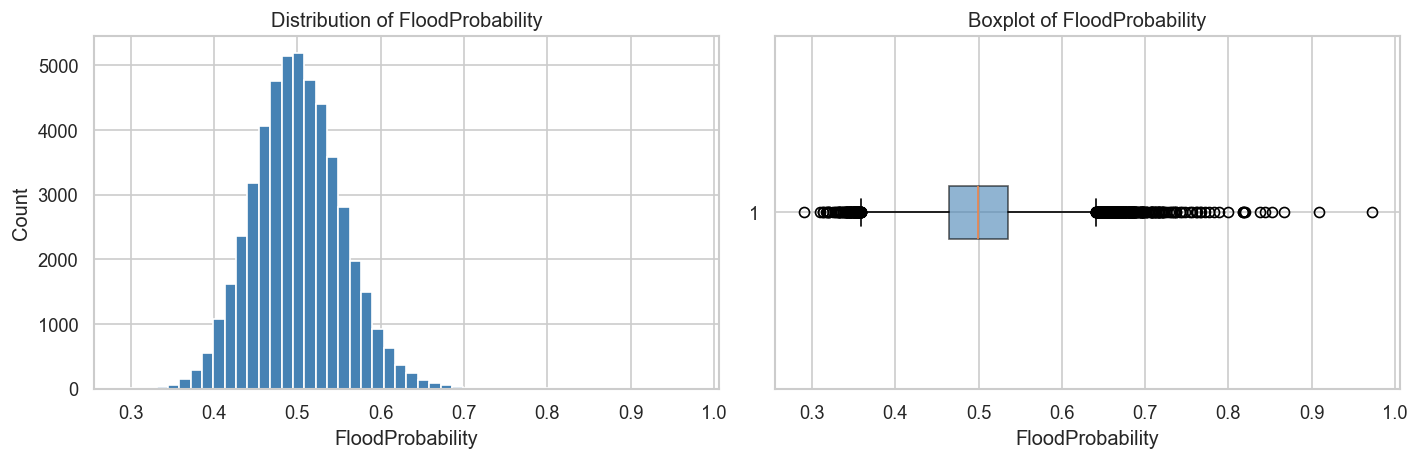

In [107]:
# Target variable distribution
print("FloodProbability summary:")
print(df_noisy["FloodProbability"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df_noisy["FloodProbability"], bins=50, color="steelblue", edgecolor="white"
)
axes[0].set_title("Distribution of FloodProbability")
axes[0].set_xlabel("FloodProbability")
axes[0].set_ylabel("Count")

# Boxplot
axes[1].boxplot(
    df_noisy["FloodProbability"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
)
axes[1].set_title("Boxplot of FloodProbability")
axes[1].set_xlabel("FloodProbability")

plt.tight_layout()
plt.show()

## 3. Summary Statistics

In [108]:
feature_cols = [c for c in df_noisy.columns if c != "FloodProbability"]

print("Summary statistics for all features:")
df_noisy[feature_cols].describe().round(2)

Summary statistics for all features:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,4.99,4.98,5.02,5.01,4.99,4.99,5.02,4.99,5.01,5.01,5.01,5.00,5.00,4.98,4.98,4.99,4.98,5.00,4.99,4.99
std,2.25,2.25,2.24,2.23,2.26,2.24,2.25,2.24,2.25,2.26,2.24,2.25,2.25,2.23,2.24,2.24,2.25,2.24,2.24,2.26
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3.30,3.06,3.21,3.21,3.28,3.30,3.20,3.29,3.32,3.31,3.33,3.32,3.06,3.05,3.17,3.18,3.29,3.31,3.29,3.28
50%,4.90,4.98,4.95,4.94,4.88,4.90,4.94,4.89,4.90,4.89,4.89,4.91,4.98,4.98,4.93,4.93,4.88,4.90,4.89,4.89
75%,6.33,6.06,6.22,6.21,6.32,6.31,6.23,6.30,6.35,6.36,6.34,6.33,6.07,6.07,6.19,6.20,6.33,6.35,6.32,6.34
max,16.09,18.00,16.13,17.19,17.39,16.72,16.01,16.37,16.10,17.93,15.86,17.12,17.07,16.14,16.22,17.24,18.75,22.09,16.31,16.42


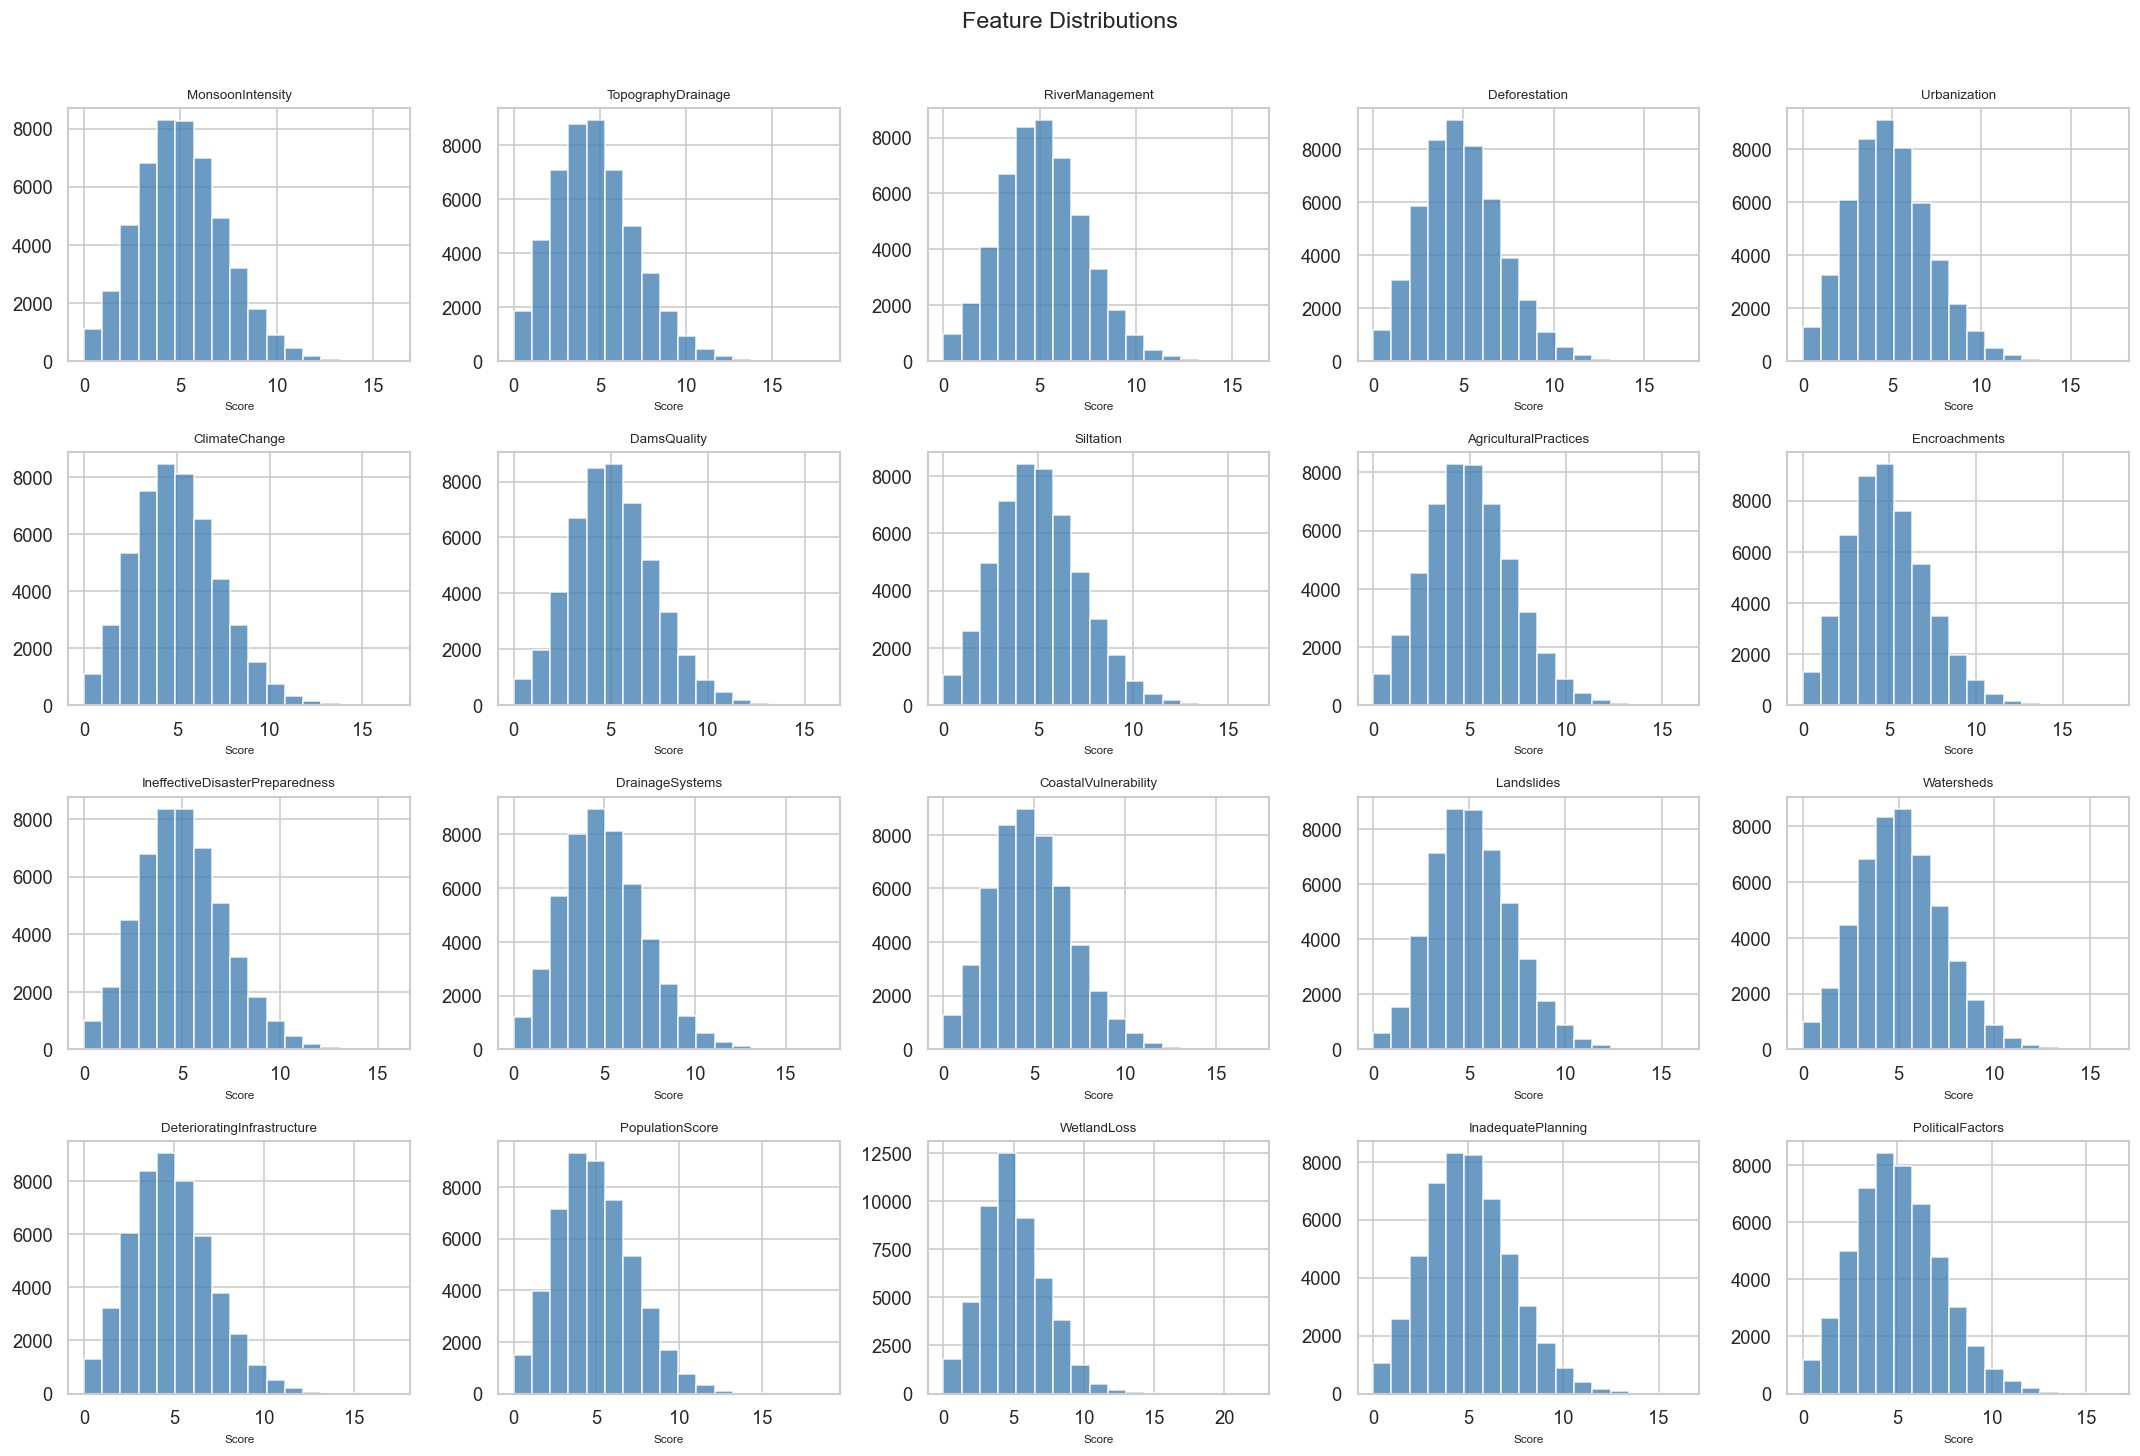

In [109]:
# Distribution of all 20 features in one grid
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(
        df_noisy[col], bins=17, color="steelblue", edgecolor="white", alpha=0.8
    )
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("Score", fontsize=7)

plt.suptitle("Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Correlation Matrix

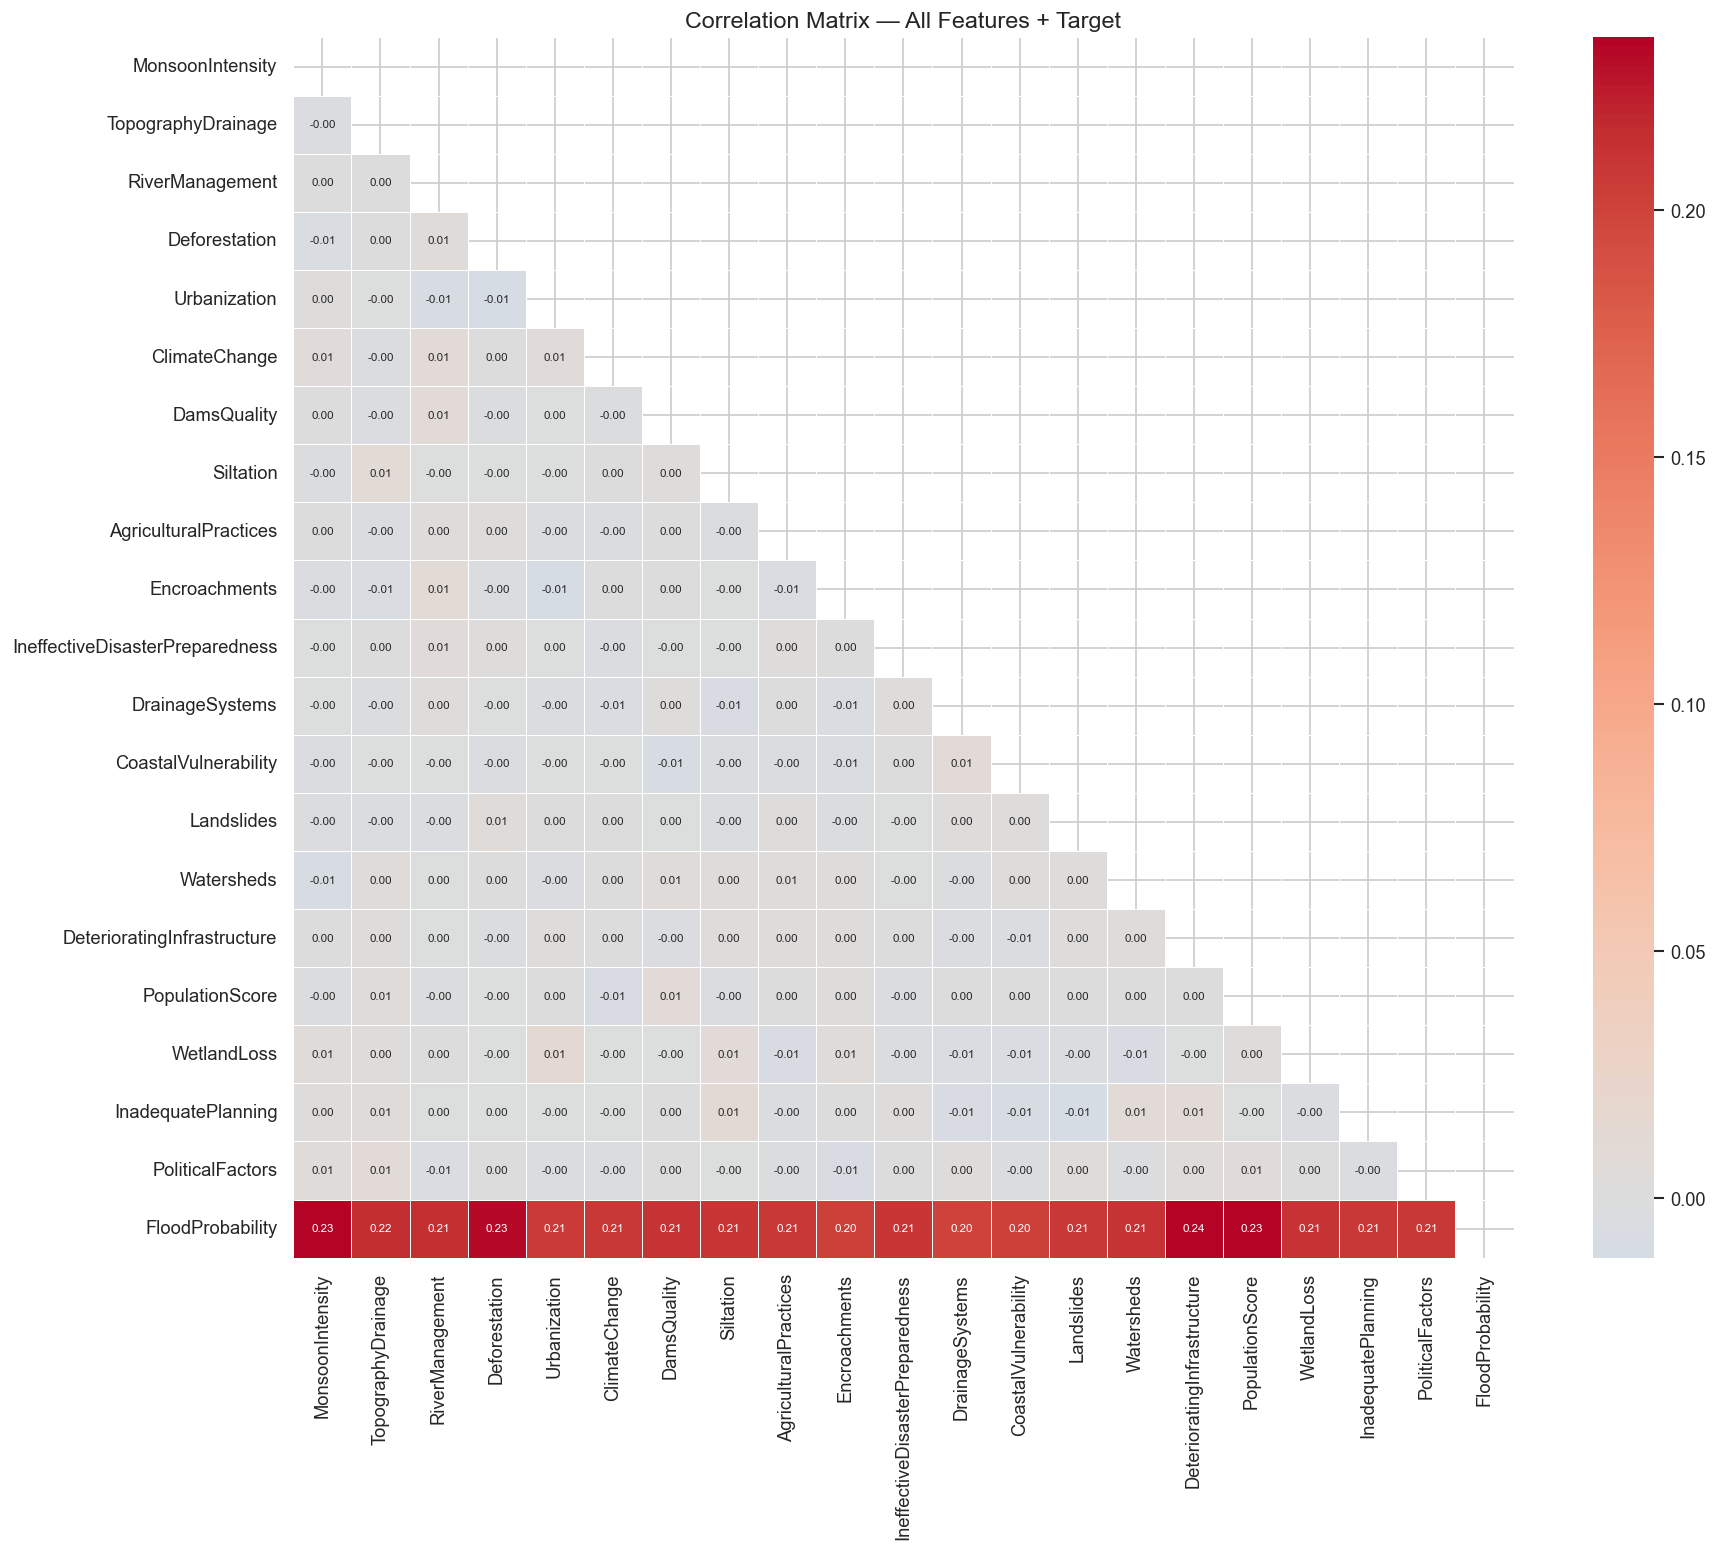

In [110]:
corr = df_noisy.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Correlation Matrix — All Features + Target", fontsize=14)
plt.tight_layout()
plt.show()

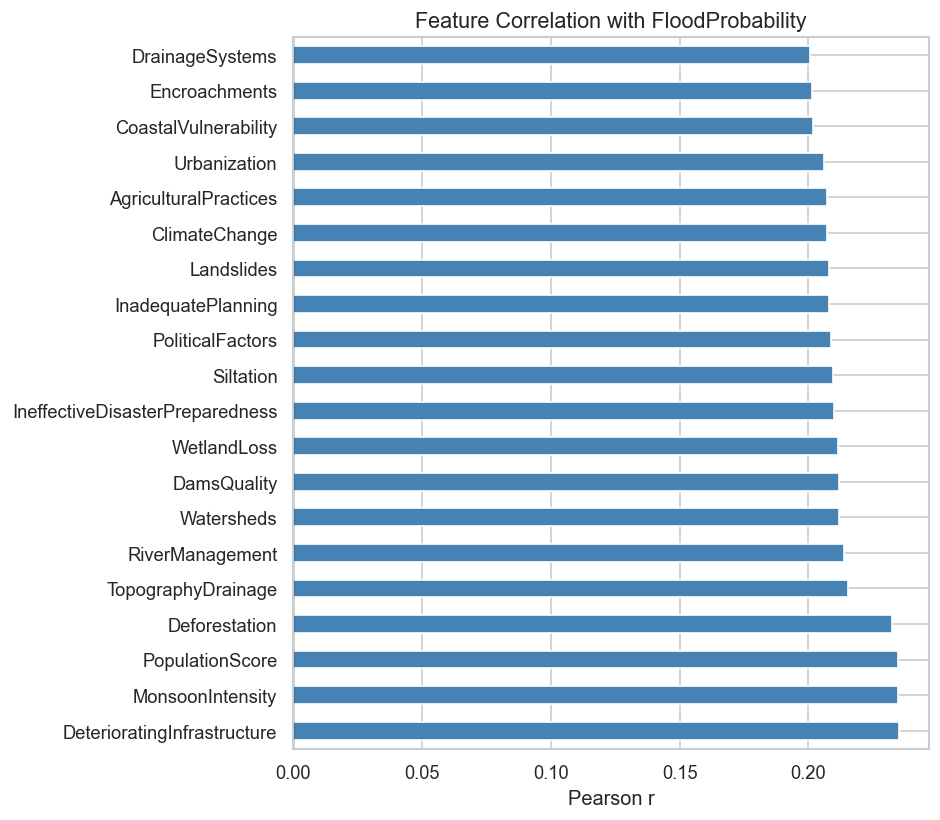


Top 5 positively correlated features:
DeterioratingInfrastructure    0.235019
MonsoonIntensity               0.234782
PopulationScore                0.234663
Deforestation                  0.232396
TopographyDrainage             0.215512
Name: FloodProbability, dtype: float64

Top 5 negatively correlated features:
AgriculturalPractices    0.207086
Urbanization             0.205951
CoastalVulnerability     0.201757
Encroachments            0.201593
DrainageSystems          0.200606
Name: FloodProbability, dtype: float64


In [111]:
# Feature correlations with target variable only, sorted
target_corr = (
    corr["FloodProbability"].drop("FloodProbability").sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if v >= 0 else "salmon" for v in target_corr]
target_corr.plot(kind="barh", color=colors, ax=ax, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with FloodProbability", fontsize=13)
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()

print("\nTop 5 positively correlated features:")
print(target_corr.head())
print("\nTop 5 negatively correlated features:")
print(target_corr.tail())

## 5. VIF Analysis (Multicollinearity Check)

In [112]:
X = df_noisy[feature_cols].copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF scores for all features:")
print(vif_data.to_string(index=False))

# Flag high VIF features
high_vif = vif_data[vif_data["VIF"] > 10]
if len(high_vif) > 0:
    print(f"\nFeatures with VIF > 10 (high multicollinearity):")
    print(high_vif.to_string(index=False))
else:
    print("\nNo features exceed VIF threshold of 10.")

VIF scores for all features:
                        Feature      VIF
                RiverManagement 5.750838
                  Deforestation 5.746863
IneffectiveDisasterPreparedness 5.707248
                     Landslides 5.707135
    DeterioratingInfrastructure 5.697704
                    DamsQuality 5.686547
                    WetlandLoss 5.678173
                     Watersheds 5.677207
          AgriculturalPractices 5.668064
             InadequatePlanning 5.667093
                  ClimateChange 5.666549
                      Siltation 5.658190
                DrainageSystems 5.649523
             TopographyDrainage 5.642480
               MonsoonIntensity 5.635480
           CoastalVulnerability 5.633793
                  Encroachments 5.626626
                PopulationScore 5.623410
               PoliticalFactors 5.599911
                   Urbanization 5.595432

No features exceed VIF threshold of 10.


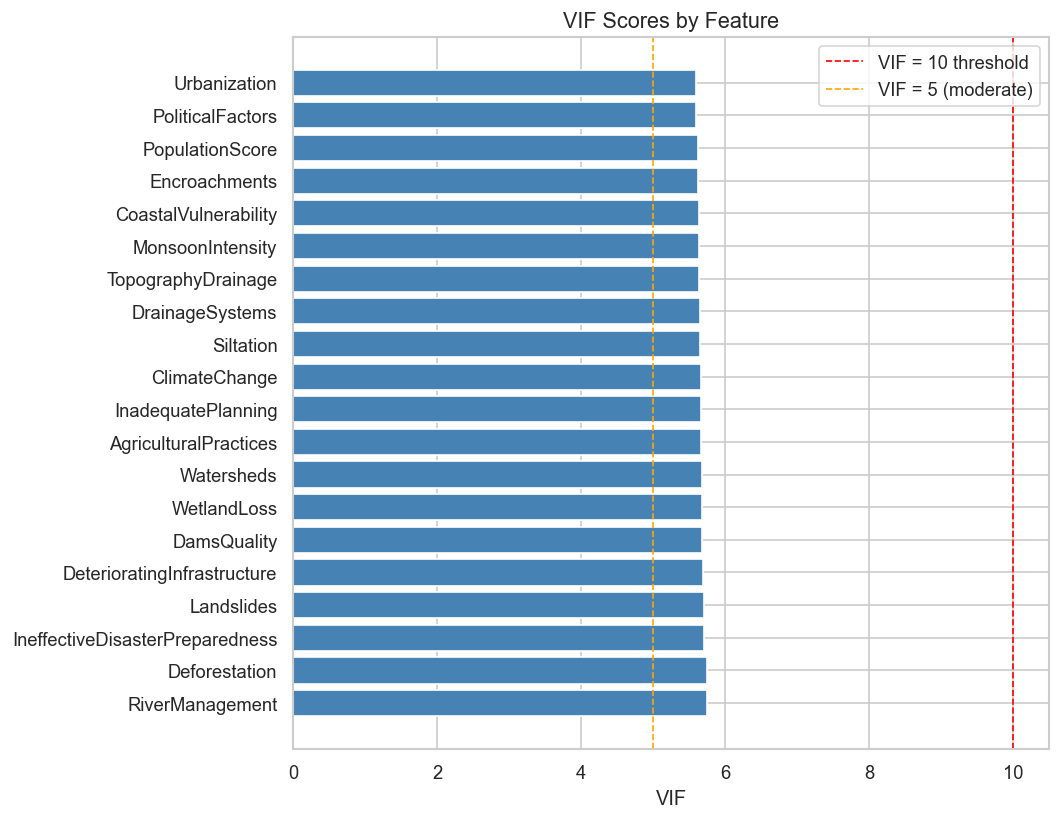

In [113]:
# VIF bar chart
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["salmon" if v > 10 else "steelblue" for v in vif_data["VIF"]]
ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors, edgecolor="white")
ax.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF = 10 threshold")
ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="VIF = 5 (moderate)")
ax.set_title("VIF Scores by Feature", fontsize=13)
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Scaling (StandardScaler)

In [114]:
X = df_noisy[feature_cols].copy()
y = df_noisy["FloodProbability"].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print("Scaled feature summary (should have mean ≈ 0, std ≈ 1):")
print(X_scaled.describe().loc[["mean", "std"]].round(4))

Scaled feature summary (should have mean ≈ 0, std ≈ 1):
      MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
mean              -0.0                -0.0              0.0            0.0   
std                1.0                 1.0              1.0            1.0   

      Urbanization  ClimateChange  DamsQuality  Siltation  \
mean          -0.0           -0.0         -0.0       -0.0   
std            1.0            1.0          1.0        1.0   

      AgriculturalPractices  Encroachments  IneffectiveDisasterPreparedness  \
mean                    0.0           -0.0                              0.0   
std                     1.0            1.0                              1.0   

      DrainageSystems  CoastalVulnerability  Landslides  Watersheds  \
mean              0.0                  -0.0         0.0        -0.0   
std               1.0                   1.0         1.0         1.0   

      DeterioratingInfrastructure  PopulationScore  WetlandLoss  \
mean  

In [115]:
# NOTE: The scaler is fit on the FULL dataset here for inspection purposes.
# In modeling, fit the scaler on the TRAINING set only and transform
# the test set using that same fitted scaler to prevent data leakage.
# See Section 7 for the correct pipeline.

## 7. Train/Test Split + 5-Fold Cross-Validation Setup

In [116]:
# 80/20 train/test split — stratified on binned FloodProbability
# to ensure similar target distributions in both splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train_raw.shape[0]:,} rows")
print(f"Test set:      {X_test_raw.shape[0]:,} rows")
print(
    f"Train target mean: {y_train.mean():.4f} | Test target mean: {y_test.mean():.4f}"
)

Training set:  40,000 rows
Test set:      10,000 rows
Train target mean: 0.5007 | Test target mean: 0.5018


In [117]:
# Fit scaler on training set ONLY — transform both train and test
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=feature_cols)

print("Scaler fit on training set only (no data leakage).")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Scaler fit on training set only (no data leakage).
X_train shape: (40000, 20)
X_test shape:  (10000, 20)


In [118]:
# 5-fold cross-validation object
# Use this kf object during model training for hyperparameter tuning
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("5-fold CV split sizes (on training set):")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    print(f"  Fold {fold}: train={len(train_idx):,} | val={len(val_idx):,}")

5-fold CV split sizes (on training set):
  Fold 1: train=32,000 | val=8,000
  Fold 2: train=32,000 | val=8,000
  Fold 3: train=32,000 | val=8,000
  Fold 4: train=32,000 | val=8,000
  Fold 5: train=32,000 | val=8,000


In [119]:
# Example usage of kf in a modeling loop:
#
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, r2_score
#
# rmse_scores, r2_scores = [], []
# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
#     X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#     y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
#
#     model = LinearRegression()
#     model.fit(X_fold_train, y_fold_train)
#     preds = model.predict(X_fold_val)
#
#     rmse_scores.append(np.sqrt(mean_squared_error(y_fold_val, preds)))
#     r2_scores.append(r2_score(y_fold_val, preds))
#
# print(f'CV RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}')
# print(f'CV R²:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}')

## 8. Save Model-Ready Datasets

In [120]:
# Save scaled train/test splits for use in modeling notebooks
X_train_out = X_train.copy()
X_train_out["FloodProbability"] = y_train.values

X_test_out = X_test.copy()
X_test_out["FloodProbability"] = y_test.values

X_train_out.to_csv("flood_train_scaled.csv", index=False)
X_test_out.to_csv("flood_test_scaled.csv", index=False)

print("Saved:")
print("  flood_train_scaled.csv  —  scaled training features + target")
print("  flood_test_scaled.csv   —  scaled test features + target")
print(f"\nTrain shape: {X_train_out.shape}")
print(f"Test shape:  {X_test_out.shape}")

Saved:
  flood_train_scaled.csv  —  scaled training features + target
  flood_test_scaled.csv   —  scaled test features + target

Train shape: (40000, 21)
Test shape:  (10000, 21)
